# UD+WALS Typology Dataset Demo

This notebook demonstrates the **UD+WALS Typology** dataset, which compiles typological metadata for 186 UD languages by joining WALS features (81A word order, 49A case count) with UD-derived case richness via ISO 639 codes.

**What this script does:**
1. Loads raw typological language records
2. Creates 3 dataset views: full typological profiles, word order prediction, and UD case richness
3. Each dataset formats language features as input/output pairs for downstream analysis

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed (only stdlib + matplotlib/pandas)

# Core packages: pre-installed on Colab, install locally to match
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-3bc3de-sentence-length-standardization-reveals-/main/dataset_iter1_ud_wals_typolog/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['total_datasets']} datasets covering {data['metadata']['total_languages']} languages")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 3 datasets covering 186 languages
  full_typological_profiles: 3 examples
  word_order_prediction: 3 examples
  ud_case_richness: 3 examples


## Helper Function

Build a JSON-string input from a language record's features (copied from original script).

In [5]:
def make_input_str(rec: dict, *, include_word_order: bool = True, include_case: bool = True) -> str:
    """Build a JSON-string input from a language record's features."""
    features = {
        "language_iso": rec["language_iso"],
        "language_name": rec["language_name"],
        "language_family": rec["language_family"],
    }
    if include_word_order and rec.get("word_order_81A"):
        features["word_order_81A"] = rec["word_order_81A"]
    if include_case:
        features["case_count_49A"] = rec.get("case_count_49A")
        features["ud_case_richness"] = rec["ud_case_richness"]
        features["ud_case_values"] = rec["ud_case_values"]
    features["latitude"] = rec.get("latitude")
    features["longitude"] = rec.get("longitude")
    features["glottocode"] = rec.get("glottocode")
    return json.dumps(features, ensure_ascii=False)

## Process Datasets

Parse each dataset's examples back into structured records for analysis.

In [6]:
# Parse examples from each dataset into DataFrames
datasets_summary = {}
for ds in data['datasets']:
    name = ds['dataset']
    rows = []
    for ex in ds['examples']:
        inp = json.loads(ex['input'])
        row = {**inp, 'output': ex['output'], 'task_type': ex.get('metadata_task_type', '')}
        rows.append(row)
    df = pd.DataFrame(rows)
    datasets_summary[name] = df
    print(f"\n--- {name} ({len(df)} examples) ---")
    print(df.to_string(index=False, max_cols=6))


--- full_typological_profiles (3 examples) ---
language_iso language_name language_family  ... glottocode             output           task_type
          ab            ab            None  ...       None ud_case_richness=0 typological_profile
         abq           abq            None  ...       None ud_case_richness=0 typological_profile
         afr            af            None  ...       None ud_case_richness=3 typological_profile

--- word_order_prediction (3 examples) ---
language_iso language_name language_family  ... glottocode  output      task_type
         amh       Amharic    Afro-Asiatic  ...   amha1245     SOV classification
         apu       Apurinã        Arawakan  ...   apur1254     SVO classification
         arh           Ika        Chibchan  ...   arhu1242     SOV classification

--- ud_case_richness (3 examples) ---
language_iso language_name language_family  ... longitude                                                                                    output  

## Visualization

**Left:** Word order distribution across languages. **Right:** UD case richness per language.

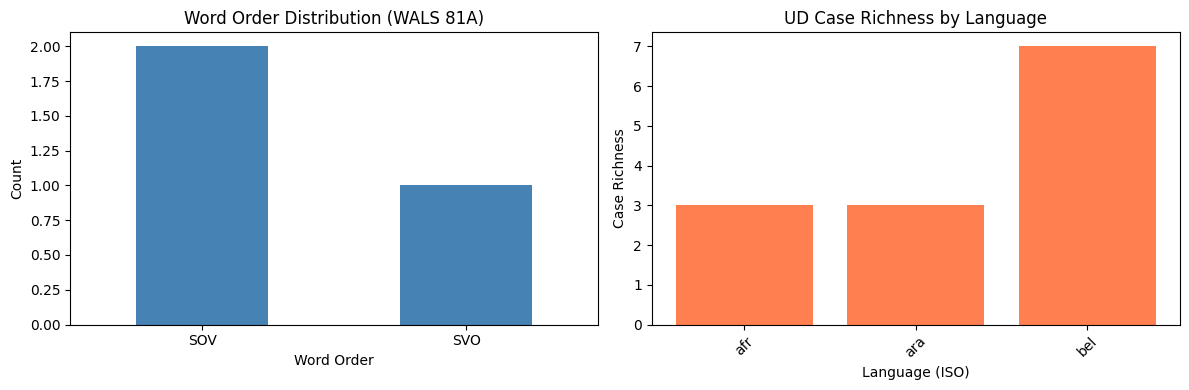

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Word order distribution
if 'word_order_prediction' in datasets_summary:
    df_wo = datasets_summary['word_order_prediction']
    df_wo['output'].value_counts().plot.bar(ax=axes[0], color='steelblue')
    axes[0].set_title('Word Order Distribution (WALS 81A)')
    axes[0].set_xlabel('Word Order')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)

# Case richness
if 'ud_case_richness' in datasets_summary:
    df_cr = datasets_summary['ud_case_richness']
    out_parsed = df_cr['output'].apply(lambda x: json.loads(x)['ud_case_richness'])
    axes[1].bar(df_cr['language_iso'], out_parsed, color='coral')
    axes[1].set_title('UD Case Richness by Language')
    axes[1].set_xlabel('Language (ISO)')
    axes[1].set_ylabel('Case Richness')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()